<a href="https://colab.research.google.com/github/AyleenSantander/M.11_Intro_AI/blob/main/M11_A9_Unsupervised_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Assignment 9: Unsupervised Learning
#Name Ayleen Santander

#Instructions

1. Dataset Selection and Preprocessing:
2. Choose a publicly available dataset suitable for a regression problem. Any dataset suitable for clustering and dimensionality reduction analysis.
3. Perform necessary preprocessing steps including:
- Handling missing values
- Feature scaling (if needed)
- One-hot encoding for categorical variables (if applicable)
- Apply any necessary transformations and normalize or standardize the data as required for your algorithms.

In [62]:
#Importing the Libraries
import numpy as np
import pandas as pd
import datetime
import matplotlib.pyplot as plt
from matplotlib import colors
import seaborn as sns
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans
from mpl_toolkits.mplot3d import Axes3D
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from matplotlib.colors import ListedColormap
from sklearn import metrics
import warnings
import sys
if not sys.warnoptions:
    warnings.simplefilter("ignore")
np.random.seed(42)

In [5]:
#Loading the dataset
mkt = pd.read_csv("/content/marketing_campaign.csv", sep="\t")
print("Number of datapoints:", len(mkt))
mkt.head()

Number of datapoints: 2240


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


#Data Cleaning

In [6]:
print(mkt.info)

<bound method DataFrame.info of          ID  Year_Birth   Education Marital_Status   Income  Kidhome  \
0      5524        1957  Graduation         Single  58138.0        0   
1      2174        1954  Graduation         Single  46344.0        1   
2      4141        1965  Graduation       Together  71613.0        0   
3      6182        1984  Graduation       Together  26646.0        1   
4      5324        1981         PhD        Married  58293.0        1   
...     ...         ...         ...            ...      ...      ...   
2235  10870        1967  Graduation        Married  61223.0        0   
2236   4001        1946         PhD       Together  64014.0        2   
2237   7270        1981  Graduation       Divorced  56981.0        0   
2238   8235        1956      Master       Together  69245.0        0   
2239   9405        1954         PhD        Married  52869.0        1   

      Teenhome Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  \
0            0  04-09-2012    

In [8]:
#Handling missing values
print("Number of rows with missing values:", len(mkt[mkt.isnull().any(axis=1)]))

Number of rows with missing values: 0


In [9]:
#To remove the NA values
mkt = mkt.dropna()
print("After removing the rows with missing values are:", len(mkt))

After removing the rows with missing values are: 2216


In [11]:
#all columns
print(mkt.columns.tolist())

['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response']


In [17]:
#Define target and features
purchase_cols = ['NumDealsPurchases','NumWebPurchases',
                 'NumCatalogPurchases','NumStorePurchases']
mkt['TotalPurchasesMonth'] = mkt[purchase_cols].sum(axis=1)

features = ['Income','NumWebVisitsMonth','Recency','Year_Birth','Kidhome','Teenhome',
            'MntWines','MntMeatProducts','MntGoldProds']
target = 'TotalPurchasesMonth'

X = mkt[features]
y = mkt[target]

print(X.shape, type(y).__name__, y.shape)
print(y.describe())

(2216, 9) Series (2216,)
count    2216.000000
mean       14.880866
std         7.670957
min         0.000000
25%         8.000000
50%        15.000000
75%        21.000000
max        44.000000
Name: TotalPurchasesMonth, dtype: float64


In [18]:
print(mkt.isna())

         ID  Year_Birth  Education  Marital_Status  Income  Kidhome  Teenhome  \
0     False       False      False           False   False    False     False   
1     False       False      False           False   False    False     False   
2     False       False      False           False   False    False     False   
3     False       False      False           False   False    False     False   
4     False       False      False           False   False    False     False   
...     ...         ...        ...             ...     ...      ...       ...   
2235  False       False      False           False   False    False     False   
2236  False       False      False           False   False    False     False   
2237  False       False      False           False   False    False     False   
2238  False       False      False           False   False    False     False   
2239  False       False      False           False   False    False     False   

      Dt_Customer  Recency 

#Part 2:Clustering:
1. Apply at least two clustering techniques (e.g., K-means clustering, Hierarchical clustering).
2. Determine the optimal number of clusters for each technique (use methods like the Elbow method, Silhouette score).
3. Present/Visualize the clusters formed.

In [28]:
#Applying inertia to find the optimal k, elbow method
inertia=[]
k_range=range(1,10)
for k in k_range:
  kmeans=KMeans(n_clusters=k, random_state=42, n_init=10)
  kmeans.fit(X)
  inertia.append(kmeans.inertia_)

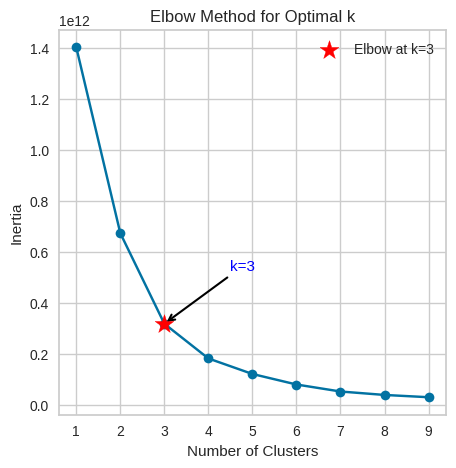

In [41]:
#Plot Elbow Method
plt.figure(figsize=(5,5))
plt.plot(k_range, inertia, marker="o")
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.xticks(list(k_range))
plt.grid(True)

#Mark the Elbow point
optimal_k = 3
y_elbow = inertia[list(k_range).index(optimal_k)]

plt.scatter(optimal_k, y_elbow, color='red', marker='*', s=200,
            label=f'Elbow at k={optimal_k}', zorder=5)
plt.annotate(f'k={optimal_k}',
             xy=(optimal_k, y_elbow),
             xytext=(optimal_k + 1.5, y_elbow + 0.15*max(inertia)),
             fontsize=11, color='blue',
             arrowprops=dict(facecolor='red', arrowstyle='->', lw=1.5))
plt.legend()
plt.show()

Elbow Method show the optimal K is when bend in k=3.

In [30]:
#Initialize K-Means Clustering
kmeans= KMeans(n_clusters=3, random_state=42)
kmeans.fit(X)

#Output cluster centers and labels
print("Cluster Centers:\n", kmeans.cluster_centers_)
print("\nCluster Labels:\n", kmeans.labels_)

Cluster Centers:
 [[3.43569412e+04 6.65894924e+00 4.90026714e+01 1.97095993e+03
  7.20391808e-01 4.69278718e-01 7.61647373e+01 3.57773820e+01
  2.26037400e+01]
 [6.95154175e+04 3.96313364e+00 4.90258065e+01 1.96657880e+03
  1.53917051e-01 5.44700461e-01 5.44090323e+02 2.99456221e+02
  6.63714286e+01]
 [2.21604500e+05 1.12500000e+00 4.86250000e+01 1.97250000e+03
  3.75000000e-01 2.50000000e-01 2.65000000e+01 6.21875000e+02
  3.75000000e+00]]

Cluster Labels:
 [1 0 1 ... 1 1 1]


In [36]:
# Silhouette score
scaler= StandardScaler()
X_scaled= scaler.fit_transform(X) #X =feature determine previous df
sil_range = range(2, 11)   # starts at 2 - k=1 has no score
sil_scores = []

for k in sil_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)
    print(f'k={k} silhouette score: {score:.3f}')

best_k = list(sil_range)[int(np.argmax(sil_scores))]
best_score = max(sil_scores)
print(f'\nBest k={best_k} (silhouette={best_score:.3f})')

k=2 silhouette score: 0.267
k=3 silhouette score: 0.234
k=4 silhouette score: 0.206
k=5 silhouette score: 0.212
k=6 silhouette score: 0.206
k=7 silhouette score: 0.207
k=8 silhouette score: 0.184
k=9 silhouette score: 0.201
k=10 silhouette score: 0.182

Best k=2 (silhouette=0.267)


Silhoutte Methods whem I applied this method shows the best k for this clusters is k=2; silhoutte = 0.267 is the best clustering.

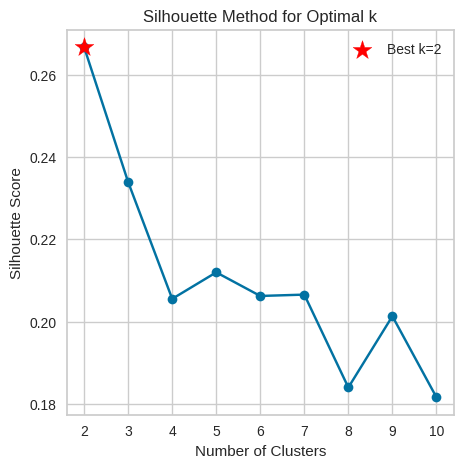

In [37]:
#Plot
plt.figure(figsize=(5,5))
plt.plot(sil_range, sil_scores, marker="o")
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Method for Optimal k')
plt.xticks(list(sil_range))
plt.grid(True)

plt.scatter(best_k, best_score, color='red', marker='*', s=200,
            label=f'Best k={best_k}', zorder=5)
plt.legend()
plt.show()

#Part 3: Dimensionality Reduction:
1. Implement a dimensionality reduction technique (PCA, t-SNE).
2. Visualize the high-dimensional data in two or three dimensions.

In [46]:
#Fit KMeans K=3
best_k= 3
kmeans =KMeans(n_clusters=best_k, random_state=42, n_init=10)
clusters=kmeans.fit_predict(X_scaled)

#PCA
pca = PCA(n_components=2, random_state=42)
X_pca= pca.fit_transform(X_scaled)
evr = pca.explained_variance_ratio_
print(f'PC1:{evr[0]:.1%}, PC2: {evr[1]}, total: {evr.sum():.1%}')

#t-SNE
tsne=TSNE(n_components=2, random_state=42, perplexity=30, init='pca')
X_tsne= tsne.fit_transform(X_scaled)


PC1:36.6%, PC2: 0.1592883753704907, total: 52.5%


Analysis:
PC1 captures 36.6% of the variance and PC2 15.9%, total 52.5% in two dimensions.
Plot 2D shows about half of what's in the daata. The other half got left out. Two dots stting next to each other on the plot might not realy be similar, they could differ in ways the picture can't show.
52.5% is on the low side. It means the data doesn't have onw or two dominant patttern, its spread thinly across many directions. That fit silhoutte (k=3;0.23-k=2;0.27), wwhich were also weak. Means the data doenst split into tidy groups.

In [78]:
#Check how many components you'd actually need:
pca_full = PCA().fit(X_scaled)
cum = np.cumsum(pca_full.explained_variance_ratio_)
print(cum.round(3))
print('For 80%:', np.argmax(cum >= 0.80) + 1, 'components')
print('For 90%:', np.argmax(cum >= 0.90) + 1, 'components')

[0.366 0.525 0.636 0.729 0.801 0.867 0.929 0.967 1.   ]
For 80%: 5 components
For 90%: 7 components


Analysis:
I have 9 features total. To keep 80% of the info need 5 components, and 90% needs 7.

The suggest from 9 columns to 7 is barely a reduction, the data doens't have a few strong pattern higging in it. Each feature is contributing something fairly independent.

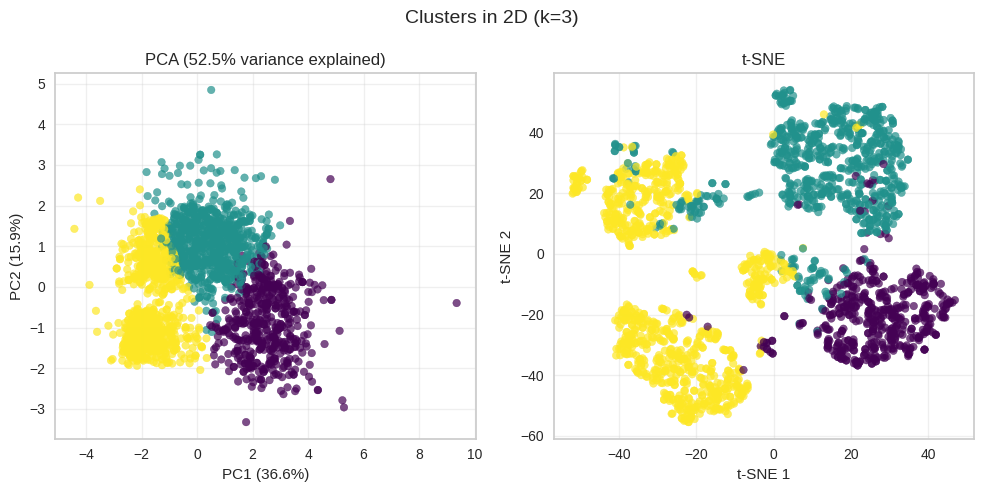

In [49]:
#Visualize the high-dimensional data in two or three dimensions.
#Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', s=30, alpha=0.7)
axes[0].set_title(f'PCA ({evr.sum():.1%} variance explained)')
axes[0].set_xlabel(f'PC1 ({evr[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({evr[1]:.1%})')

axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=clusters, cmap='viridis', s=30, alpha=0.7)
axes[1].set_title('t-SNE')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')

for ax in axes:
    ax.grid(alpha=0.3)

fig.suptitle(f'Clusters in 2D (k={best_k})', fontsize=14)
plt.tight_layout()
plt.show()

PCA vs t-SNE. PCA is linear and the axes mean something — PC1 is the direction of greatest variance, and pca.components_ tells you which original features load onto it. Distances between points are meaningful. t-SNE is nonlinear and only preserves local neighbourhoods; cluster sizes and the gaps between clusters on a t-SNE plot carry no information.

#Model Evaluation:
1. Evaluate the models using appropriate metrics (e.g., Silhouette score).
2. Interpret and document the results.


In [77]:
#1.Evaluate the models using appropriate metrics
results = []

def evaluate(name, labels, X=X_scaled):
    labels = np.asarray(labels)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = int(np.sum(labels == -1))

    # Metrics need at least 2 clusters; exclude noise points for DBSCAN/HDBSCAN
    mask = labels != -1

    if n_clusters < 2 or mask.sum() < 3:
        results.append({
            'Model': name,
            'Clusters': n_clusters,
            'Noise': n_noise,
            'Silhouette': np.nan,
            'Calinski-Harabasz': np.nan,
            'Davies-Bouldin': np.nan,
        })
        print(f'Model: {name} — only {n_clusters} cluster(s), metrics skipped')
        return

    results.append({
        'Model': name,
        'Clusters': n_clusters,
        'Noise': n_noise,
        'Silhouette': silhouette_score(X[mask], labels[mask]),
        'Calinski-Harabasz': calinski_harabasz_score(X[mask], labels[mask]),
        'Davies-Bouldin': davies_bouldin_score(X[mask], labels[mask]),
    })

In [76]:
#Models
km=KMeans(n_clusters=3, random_state=42, n_init=10)
evaluate('KMeans (k=3)', km.fit_predict(X_scaled))

km2=KMeans(n_clusters=2, random_state=42,n_init=10)
evaluate('KMeans (k=2)', km2.fit_predict(X_scaled))

agg=AgglomerativeClustering(n_clusters=3, linkage='ward')
evaluate('Hierarchical (k=3)', agg.fit_predict(X_scaled))

db=DBSCAN(eps=0.5, min_samples=5)
evaluate('DBSCAN', db.fit_predict(X_scaled))

comparison=pd.DataFrame(results)
print(comparison.round(3).to_string(index=False))

             Model  Clusters  Noise  Silhouette  Calinski-Harabasz  Davies-Bouldin
      KMeans (k=3)         3      0       0.234            687.200           1.617
      KMeans (k=2)         2      0       0.267            844.285           1.535
Hierarchical (k=3)         3      0       0.201            612.563           1.771
            DBSCAN        10   1910       0.048             30.488           0.967


Interpretation:
Silhoutte = k=2 higher and close to 1, this means the points are closed between them.
Calinski-Harabasz= Higher, mean the clustering was right
Davies-Bouldin= lower(0 is the best), means the distance between clusters has good distance between them, they meet both conditions cohesion and distance.
DBSCAN= flagged 1910 points as noise across 10 clusters. That's eps=0.5 being too tight for this data — it's labelling most of the dataset as outliers and clustering the leftovers.
Davies-Bouldin says DBSCAN is best (0.967, lowest) while the other two metrics rank it worst. That's the noise exclusion — after dropping 1910 points you're scoring only the tight remainder, which naturally looks compact.

#Part 5: Deployment and Monitoring:
1. Discuss a hypothetical scenario where your best-performing model is deployed to production.
2. Include potential challenges in deployment, such as latency, scalability, and maintenance.
3. Propose strategies for model monitoring and updating as new data becomes available.

#1. Discuss a hypothetical scenario where your best-performing model is deployed to production.
I refer to eps was too small, no enough neighbours within the radius, so most point became a noise and get many tiny clusters. Noise = 1910 points, 10 clusters. A value of 0.5, whithin half a standardized distance unit, which is tight for data with many dimensions, distance grow as dimensions increase, so the same eps gets stricter the more features have.

KMeans model is deployed as a segmentation API. New records are scaled with the saved StandardScaler and assigned a cluster label, which feeds marketing and reporting.

The scaler must ship with the model, refitting it in production would silently shift every assignment. Column order must match training too, since a mismatch returns wrong labels without erroring.

k=2 scores best on all three metrics, but k=3 may be more useful in practice. Profile both on the original features and pick the one whose segments a business owner can actually name.

Since clustering is unsupervised, nothing alerts you when it breaks. Monitor cluster sizes, average distance to centroid, and input drift; re-fit quarterly.

#Challenges:
Latency= scoring is fast, the pipelin around it(fetching, scaling) is the bottleneck.
Scalability= scoring scales, re-training, doesn't. Use MiniBatchKMeans or a sample on large data.
Maintenance= scaler, model and column ordeer must be versioned together. Cluster IDs reshuffle on every re-fit, so remap byy cetroid proximity or dasboards swap segments silently.

#Monitoring and updating

Track cluster sizes, mean distance to centroid, and input drift vs. the training baseline.
Re-fit quarterly or when a metric crosses threshold.
Validate the new model on silhouette and segment stability before promoting; keep the old version for rollback.